In [897]:
import cleaning_preprocessing
import importlib

importlib.reload(cleaning_preprocessing)

<module 'cleaning_preprocessing' from '/Users/matthewliew/STAT 246/Final Project/cleaning_preprocessing.py'>

In [898]:
import pandas as pd
import numpy as np
from cleaning_preprocessing import preproccesing

importlib.reload(cleaning_preprocessing)

df = pd.read_csv("ames_housing.csv")
ames, column_breakdown = preproccesing(df)

location_land_all = sum(column_breakdown["location_land"].values(), [])
building_type__age_all = sum(column_breakdown["building_type_age"].values(), [])
quality_and_condition_all = sum(column_breakdown["quality_condition"].values(), [])
size_rooms_all = sum(column_breakdown["size_rooms"].values(), [])
basement_garage_all = sum(column_breakdown["basement_garage"].values(), [])
sale_all = sum(column_breakdown["sale"].values(), [])

categorical_vars = [col for family in column_breakdown.values() for col in family.get("categorical", [])]
numerical_vars = [col for family in column_breakdown.values() for col in family.get("numerical", [])]
ordinal_vars = [col for family in column_breakdown.values() for col in family.get("ordinal", [])]
all_feature_vars = [col for family in column_breakdown.values() for group in family.values() for col in group]

X = ames[all_feature_vars]
y_cat, y = ames["HighSalePrice"], ames["SalePrice"]

In [899]:
ames["Pool_QC"]

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
2925    0.0
2926    0.0
2927    0.0
2928    0.0
2929    0.0
Name: Pool_QC, Length: 2930, dtype: float64

In [900]:
X.isna().mean().sort_values(ascending=False)

Bsmt_Qual         0.000683
Electrical        0.000341
MS_Zoning         0.000000
Garage_Yr_Blt     0.000000
Garage_Cars       0.000000
                    ...   
Mas_Vnr_Area      0.000000
Year_Remod_Add    0.000000
Year_Built        0.000000
Central_Air       0.000000
Misc_Val          0.000000
Length: 79, dtype: float64

In [901]:
len(all_feature_vars)

79

In [902]:
ames[all_feature_vars]

,MS_Zoning,Neighborhood,Lot_Config,Street,Alley,Condition_1,Condition_2,Lot_Area,Lot_Frontage,Lot_Shape,...,BsmtFin_Type_2,Garage_Qual,Garage_Cond,Sale_Type,Sale_Condition,Misc_Feature,Yr_Sold,Mo_Sold_Sin,Mo_Sold_Cos,Misc_Val
0,RL,NAmes,Corner,Pave,None,Norm,Norm,31770,141.0,3,...,Unf,3,3,WD,Normal,No Feature,2010,5.000000e-01,-8.660254e-01,0
1,RH,NAmes,Inside,Pave,None,Feedr,Norm,11622,80.0,4,...,LwQ,3,3,WD,Normal,No Feature,2010,1.224647e-16,-1.000000e+00,0
2,RL,NAmes,Corner,Pave,None,Norm,Norm,14267,81.0,3,...,Unf,3,3,WD,Normal,Gar2,2010,1.224647e-16,-1.000000e+00,12500
3,RL,NAmes,Corner,Pave,None,Norm,Norm,11160,93.0,4,...,Unf,3,3,WD,Normal,No Feature,2010,8.660254e-01,-5.000000e-01,0
4,RL,Gilbert,Inside,Pave,None,Norm,Norm,13830,74.0,3,...,Unf,3,3,WD,Normal,No Feature,2010,1.000000e+00,6.123234e-17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Mitchel,CulDSac,Pave,None,Norm,Norm,7937,37.0,3,...,Unf,3,3,WD,Normal,No Feature,2006,1.000000e+00,6.123234e-17,0
2926,RL,Mitchel,Inside,Pave,None,Norm,Norm,8885,68.0,3,...,ALQ,3,3,WD,Normal,No Feature,2006,1.224647e-16,-1.000000e+00,0
2927,RL,Mitchel,Inside,Pave,None,Norm,Norm,10441,62.0,4,...,Unf,0,0,WD,Normal,Shed,2006,-5.000000e-01,-8.660254e-01,700
2928,RL,Mitchel,Inside,Pave,None,Norm,Norm,10010,77.0,4,...,LwQ,3,3,WD,Normal,No Feature,2006,8.660254e-01,-5.000000e-01,0


In [903]:
mask = X.notna().all(axis=1)
X = X.loc[mask]
y = y.loc[mask]
y_cat = y_cat.loc[mask]

In [904]:
X

,MS_Zoning,Neighborhood,Lot_Config,Street,Alley,Condition_1,Condition_2,Lot_Area,Lot_Frontage,Lot_Shape,...,BsmtFin_Type_2,Garage_Qual,Garage_Cond,Sale_Type,Sale_Condition,Misc_Feature,Yr_Sold,Mo_Sold_Sin,Mo_Sold_Cos,Misc_Val
0,RL,NAmes,Corner,Pave,None,Norm,Norm,31770,141.0,3,...,Unf,3,3,WD,Normal,No Feature,2010,5.000000e-01,-8.660254e-01,0
1,RH,NAmes,Inside,Pave,None,Feedr,Norm,11622,80.0,4,...,LwQ,3,3,WD,Normal,No Feature,2010,1.224647e-16,-1.000000e+00,0
2,RL,NAmes,Corner,Pave,None,Norm,Norm,14267,81.0,3,...,Unf,3,3,WD,Normal,Gar2,2010,1.224647e-16,-1.000000e+00,12500
3,RL,NAmes,Corner,Pave,None,Norm,Norm,11160,93.0,4,...,Unf,3,3,WD,Normal,No Feature,2010,8.660254e-01,-5.000000e-01,0
4,RL,Gilbert,Inside,Pave,None,Norm,Norm,13830,74.0,3,...,Unf,3,3,WD,Normal,No Feature,2010,1.000000e+00,6.123234e-17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,RL,Mitchel,CulDSac,Pave,None,Norm,Norm,7937,37.0,3,...,Unf,3,3,WD,Normal,No Feature,2006,1.000000e+00,6.123234e-17,0
2926,RL,Mitchel,Inside,Pave,None,Norm,Norm,8885,68.0,3,...,ALQ,3,3,WD,Normal,No Feature,2006,1.224647e-16,-1.000000e+00,0
2927,RL,Mitchel,Inside,Pave,None,Norm,Norm,10441,62.0,4,...,Unf,0,0,WD,Normal,Shed,2006,-5.000000e-01,-8.660254e-01,700
2928,RL,Mitchel,Inside,Pave,None,Norm,Norm,10010,77.0,4,...,LwQ,3,3,WD,Normal,No Feature,2006,8.660254e-01,-5.000000e-01,0


In [906]:
X = pd.get_dummies(X, columns = categorical_vars, drop_first=True)

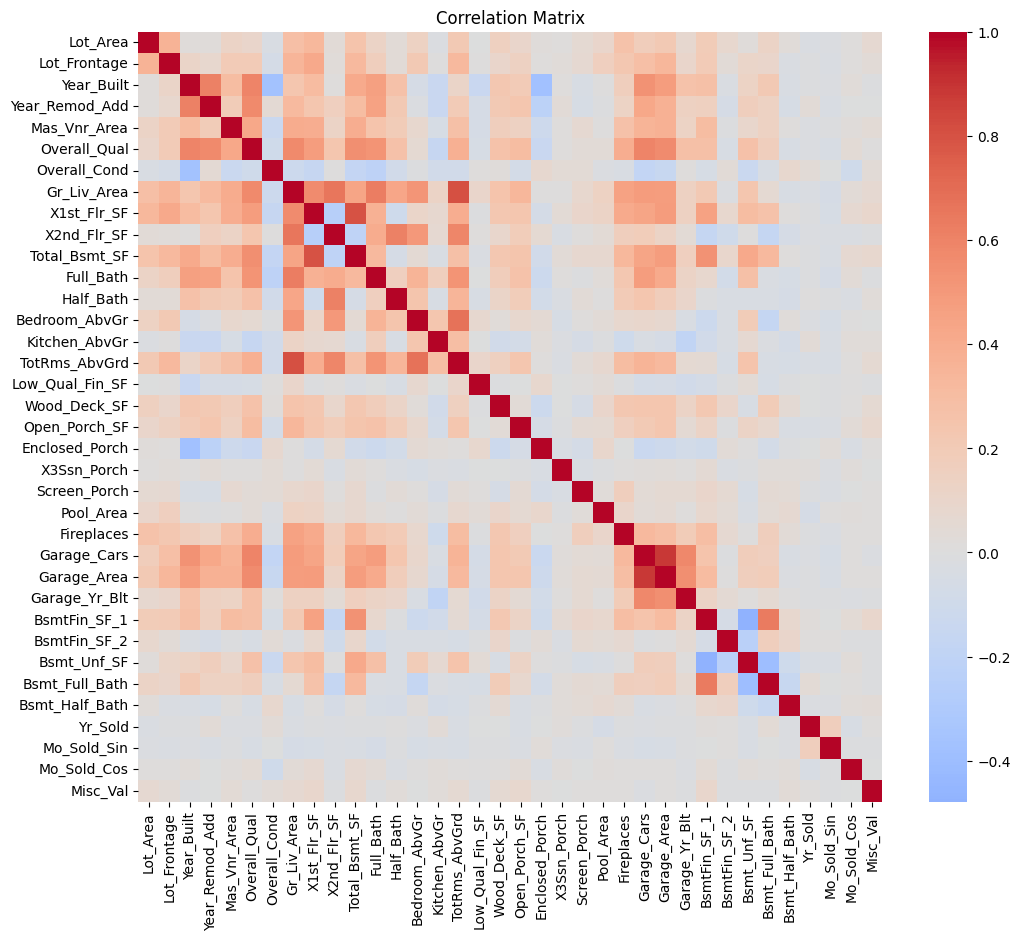

In [907]:
import matplotlib.pyplot as plt
import seaborn as sns

X_num = X[numerical_vars]

# remove constant columns
# X_num = X_num.loc[:, X_num.nunique() > 1]

corr_matrix = X_num.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Matrix")
plt.show()

In [885]:
print(X_num.shape)

(13, 36)


In [908]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

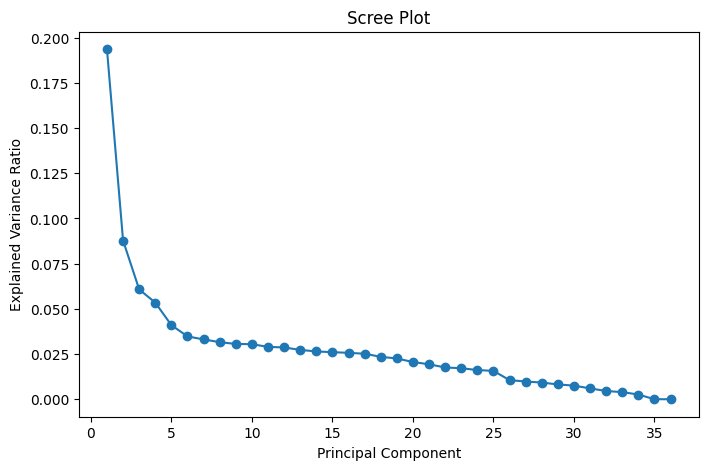

In [909]:
import matplotlib.pyplot as plt
import numpy as np

# explained variance ratio
explained_var = pca.explained_variance_ratio_

# scree plot
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.show()

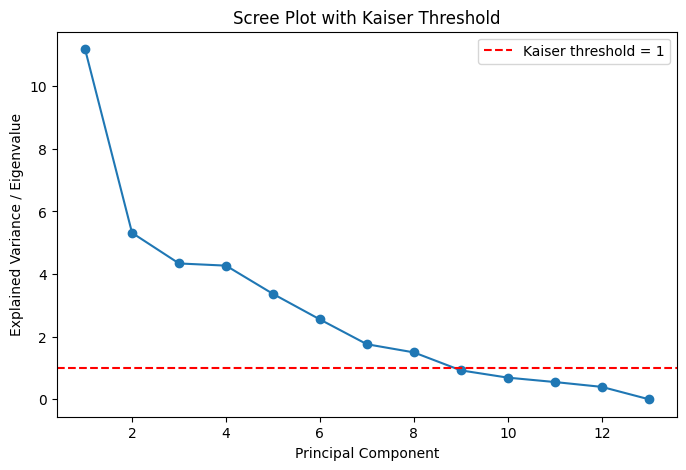

In [888]:
import matplotlib.pyplot as plt
import numpy as np

# explained variance = eigenvalues
explained_var = pca.explained_variance_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_var) + 1),
    explained_var,
    marker="o"
)

# Kaiser threshold
plt.axhline(
    y=1,
    linestyle="--",
    color="red",
    label="Kaiser threshold = 1"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance / Eigenvalue")
plt.title("Scree Plot with Kaiser Threshold")
plt.legend()

plt.show()

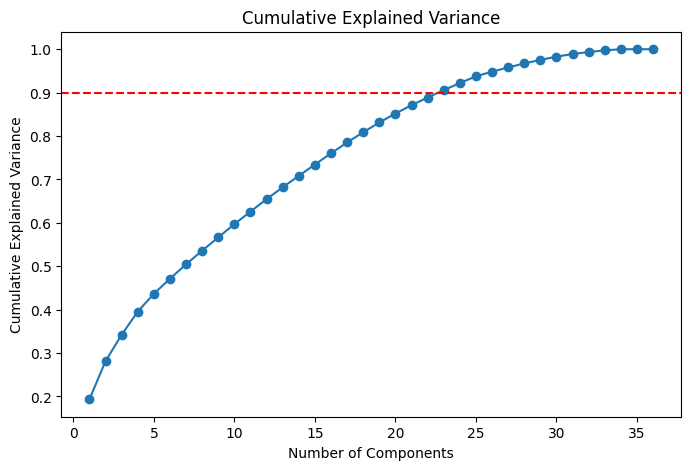

In [910]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_var) + 1),
    np.cumsum(explained_var),
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.axhline(y=0.90, color='red', linestyle='--')

plt.show()

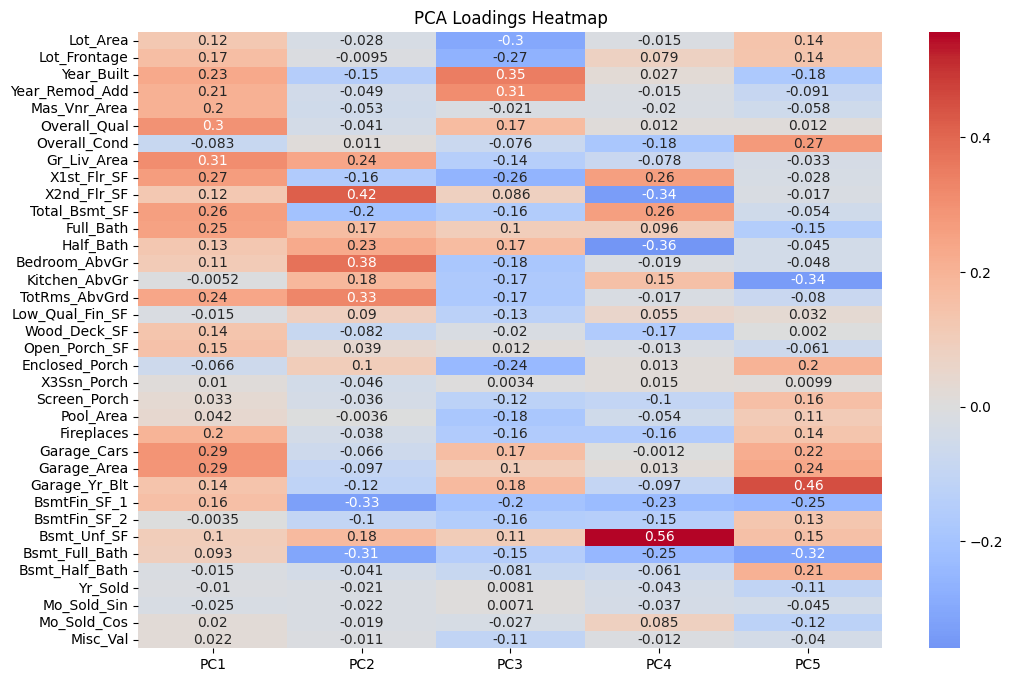

In [911]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loadings matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X_num.columns
)

# plot first 5 PCs
plt.figure(figsize=(12, 8))

sns.heatmap(
    loadings.iloc[:, :5],
    annot=True,
    fmt=".2g",
    cmap="coolwarm",
    center=0
)

plt.title("PCA Loadings Heatmap")
plt.show()

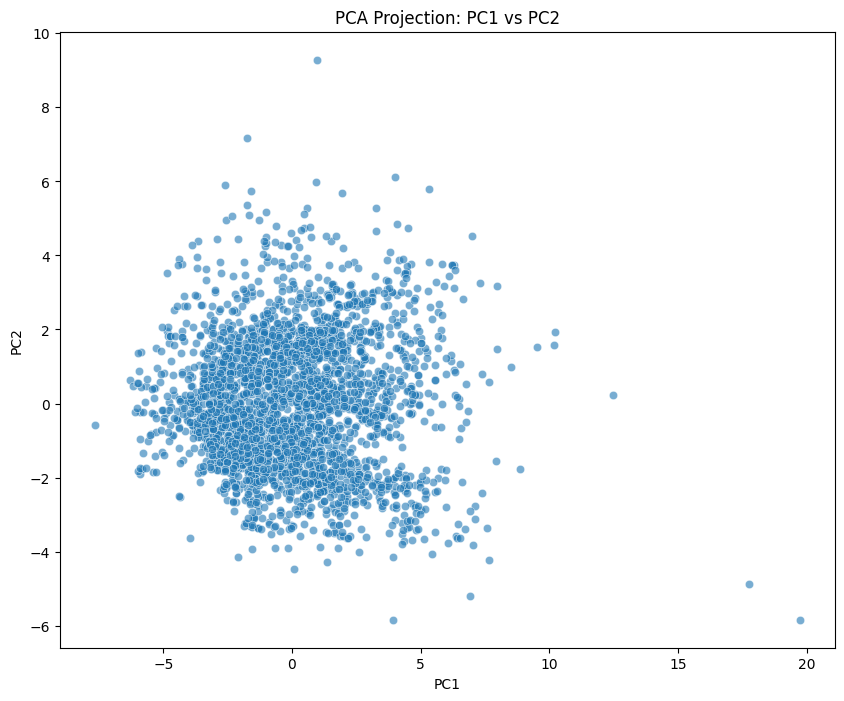

In [912]:
import pandas as pd

pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

pca_df["SalePrice"] = ames["SalePrice"]
pca_df["Overall_Qual"] = ames["Overall_Qual"]
pca_df["Neighborhood"] = ames["Neighborhood"]

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    alpha=0.6
)

plt.title("PCA Projection: PC1 vs PC2")

plt.show()

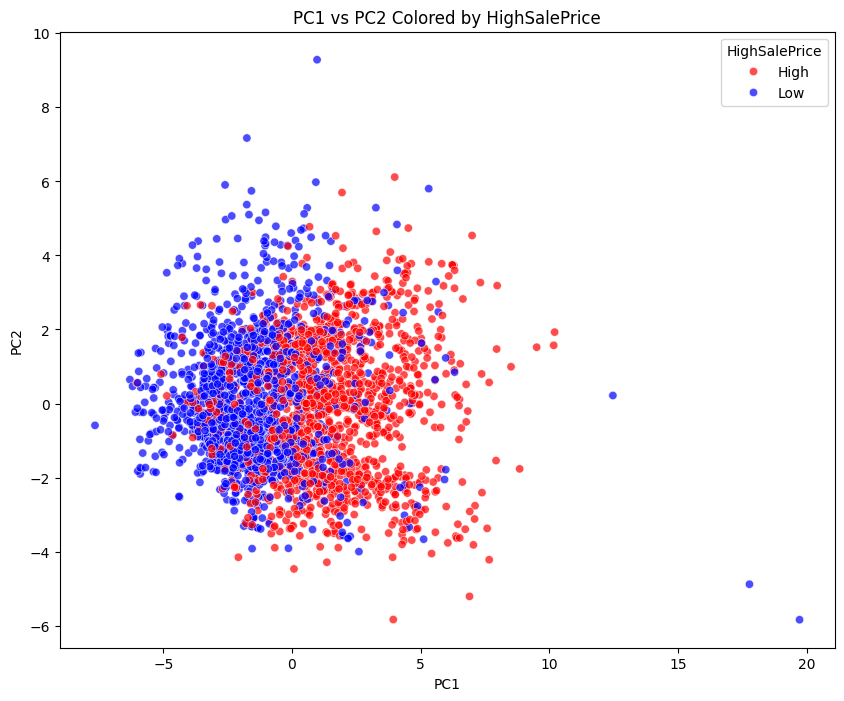

In [913]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=ames["HighSalePrice"],
    palette={"Low": "blue", "High": "red"},
    alpha=0.7
)
plt.title("PC1 vs PC2 Colored by HighSalePrice")
plt.show()

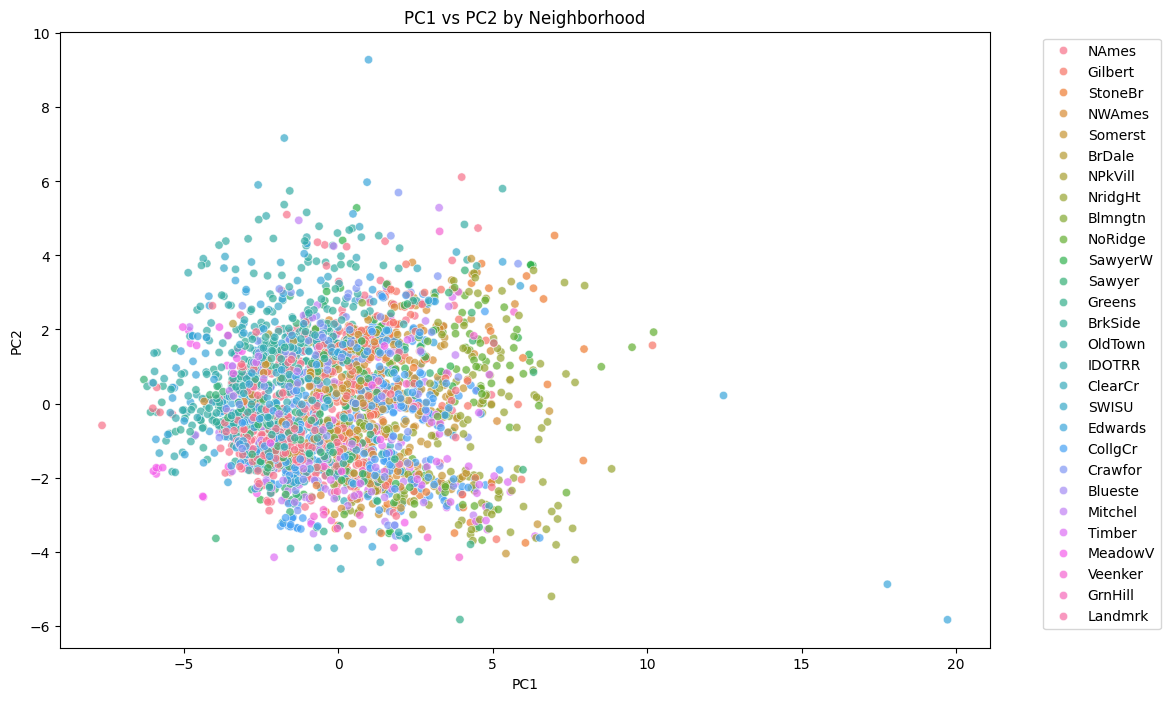

In [915]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Neighborhood",
    alpha=0.7
)

plt.title("PC1 vs PC2 by Neighborhood")

plt.legend(bbox_to_anchor=(1.05, 1))

plt.show()